#HT 3: Online Convex Optimization

В этом задании нужно добавить ускоренный алгоритм ADAM (см Algorithm 19 в прикрепленной кнжике OCO2019.pdf)

### Итого протестировать нужно уже реализованные алгоритмы применительно к задаче SVM:
* Gradient Descent(gd) - OLD
* Stochastic Gradient Descent (sgd) - OLD
* Stochastic Mirror Descent (smd) - OLD
* AdaGrad (adagrad) - OLD
* Adam (adam) - NEW

### В результатах тестирования нужны три графика: Loss, Accuracy(это было в семинрах) + Time (время обучения)

### Протокол тестирования изменяется следующим образом:
Если на семинаре мы рассматривали стандартный подход, тренировали на трейновом датасете, а потом смотрели, что получалось на тесте.

То сейчас мы и тренируем модель на трейне и сразу тестируемся. Т.е в на первом шаге мы делаем какое-то предсказние -> затем у нас появляется первый семпл с датасета -> мы сравниваем наше предсказание и залогированный лейбл, теперь у нас появляется целый один семпл в тренировочном датасете. Далее, мы тренируемся на этом одном семпле, делаем предсказание на второй лейбл, сравниваем... у нас теперь целых два семпла в тренировочном датасете И.Т.Д Для такого протокола тестирования достаточно использовать mnist_train.csv

### Итого оценки накапливаютя следующим образом:

1) Просто реализовали Adam (но тетировали только как в семинаре) = + 5 баллов
2) Добавили вычисления времени обучения = + 2 балла
3) Изменили протокол тестирования = + 3 балла

### P.S.1 В начале идет копия семинара с реализациями всех методов, спускайся вниз для реализации ДЗ, удачи ))

### P.S.2 В ячейках реализация для nepoch = 100, чтобы проверить работоспособность. Вам на трейне нужно реалиpjdfnm 50000 nepoch или больше.))





# **Тогда**: Seminar 4

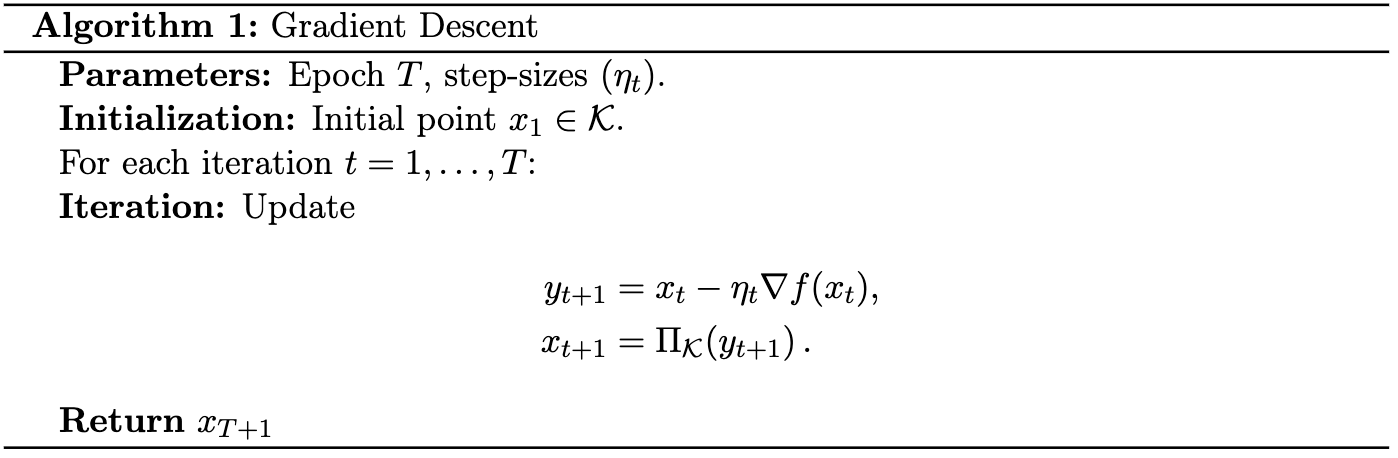

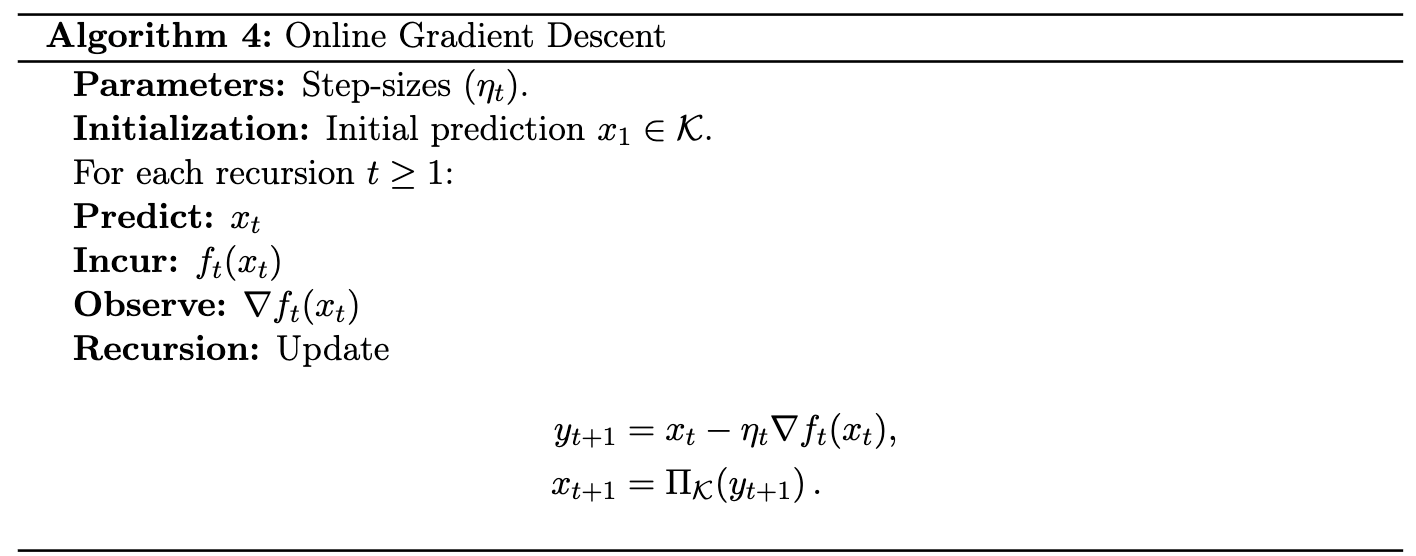

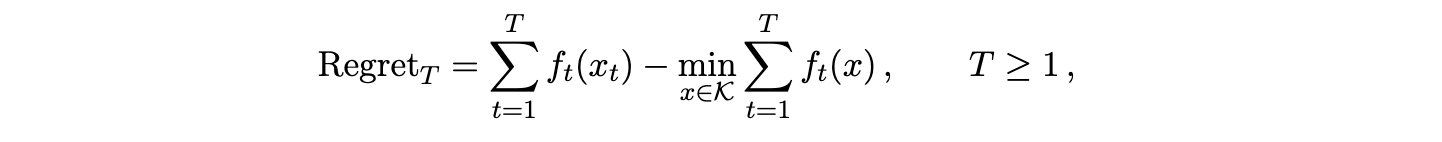

**Consider the supervised classification problem of**

* 2 classes $b_i$ ={+1, -1}

* where we observe labels $b_i$, 1 ≤ i ≤ n, bi ∈ {+1, -1}

* and explanatory variables $a_i \in R^d$

**Linear Support Vector Machine** (SVM)

are classifiers of the form $sign(x^T a_i)$

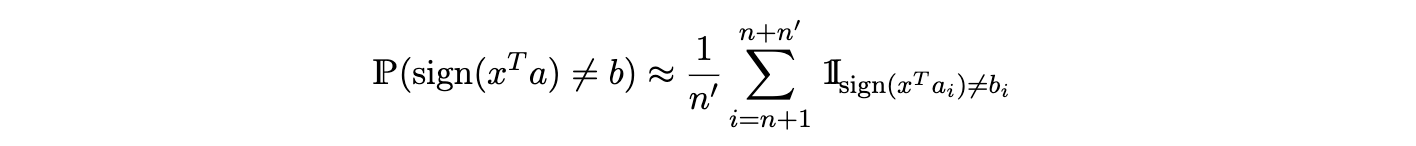

**НО В ЧЕМ ПРОБЛЕМА?**

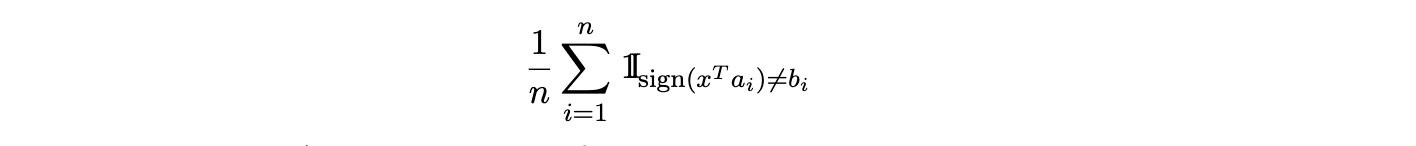

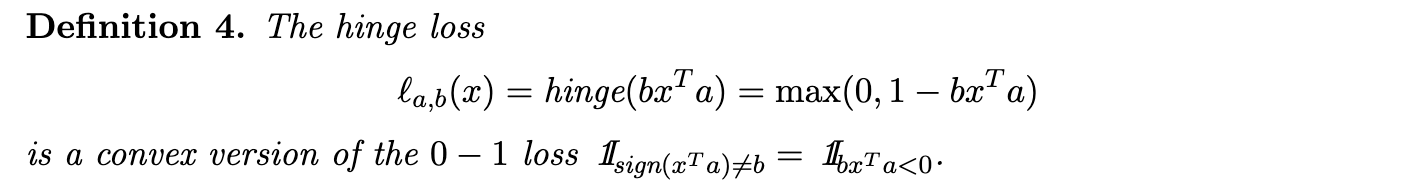

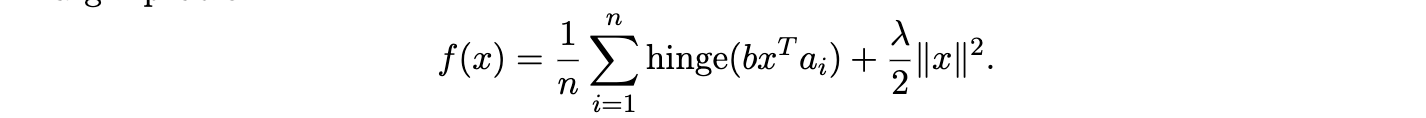

In [1]:
import numpy as np
import pandas as pd
import random as rd
import matplotlib.pyplot as plt

In [2]:
class LinearSVM:
    def __init__(self, m):
        self.w = np.random.randn(m)

    def loss(self, a, b, l):
        hinge = 1 - (a.dot(self.w)*b)
        hinge[np.where(hinge <= 0)] = 0
        return np.mean(hinge) + l/2*np.linalg.norm(self.w, 2)**2

    def gradLoss(self, a, b, l):

        if b.shape != ():
            grad = (-np.repeat(b[:, np.newaxis], a.shape[1], 1)) * a
        else:
            grad = - b * a
        temp = 1 - (a.dot(self.w)*b)
        grad[np.where(temp <= 0)] = 0
        return np.mean(grad) + l*self.w

    def predict(self, data):
        return np.sign(data.dot(self.w))

Gradient Descent

In [3]:
def gd(model, X, y, epoch, l, verbose = 0, lr = 1):
    """
    Unconstrained GD
    :param model: the model
    :param X: (nxm) data
    :param y: (n)  labels
    :param epoch: (int) maximum number of iteration of the algorithm np.array(wts)
    :param lr: (float) learning rate
    :param l:  (float) regularization parameter (lambda)
    :param verbose: (int) print epoch results every n epochs
    """
    losses = []
    wts = [model.w]

    for i in range(epoch):
        t = i + 1
        dlr = lr/(l*t)
        new_wts = wts[-1] - dlr* model.gradLoss(X, y, l)
        wts.append(new_wts)
        model.w = new_wts
        current_loss = model.loss(X, y, l)
        losses += [current_loss]

        if verbose > 0 and i % verbose== 0:
            print(f"Epoch {i}, Loss {current_loss}")

    return losses, np.array(wts)

Stochastic Gradient Descent

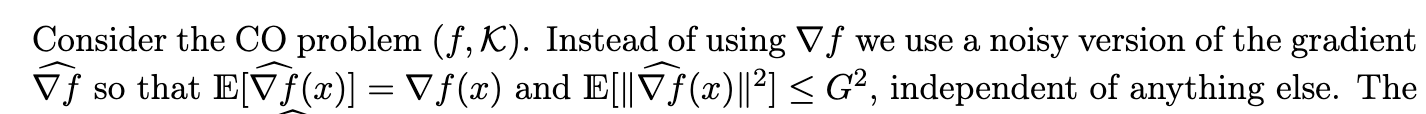


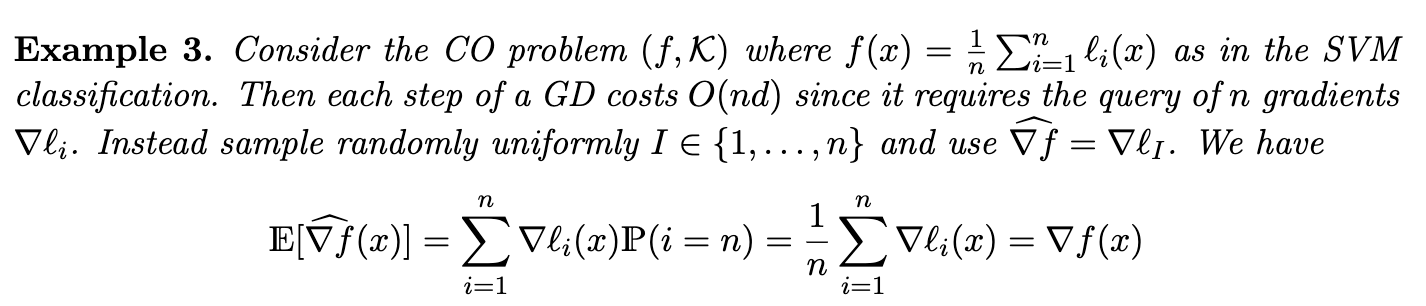

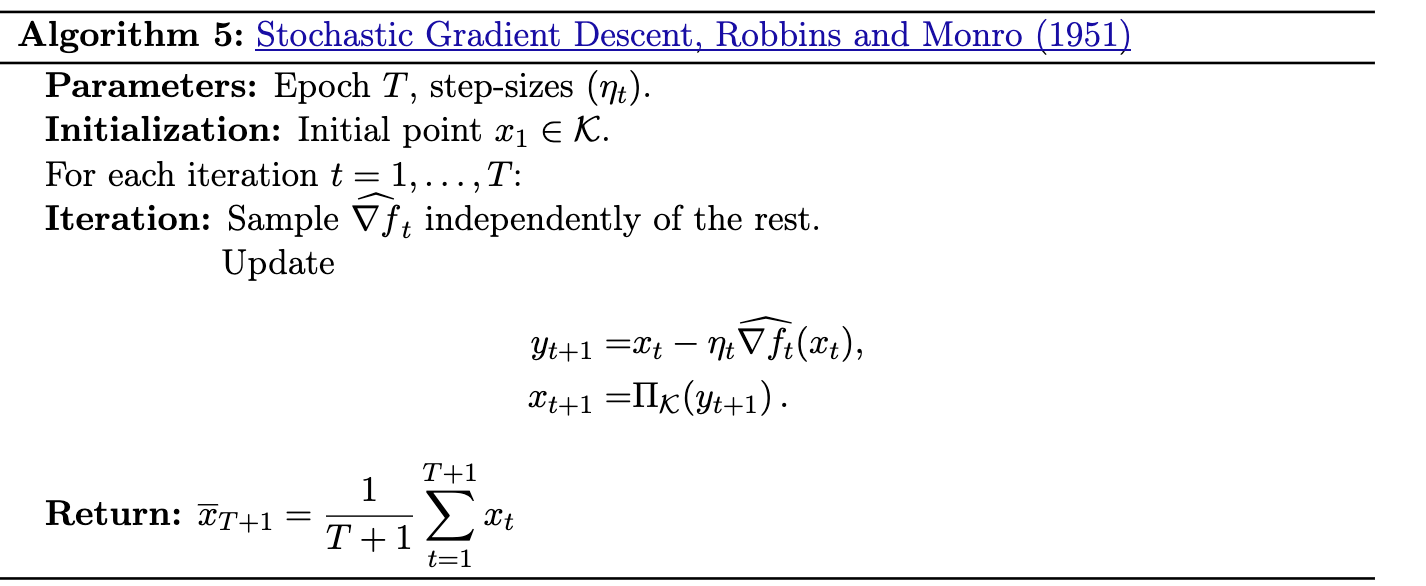

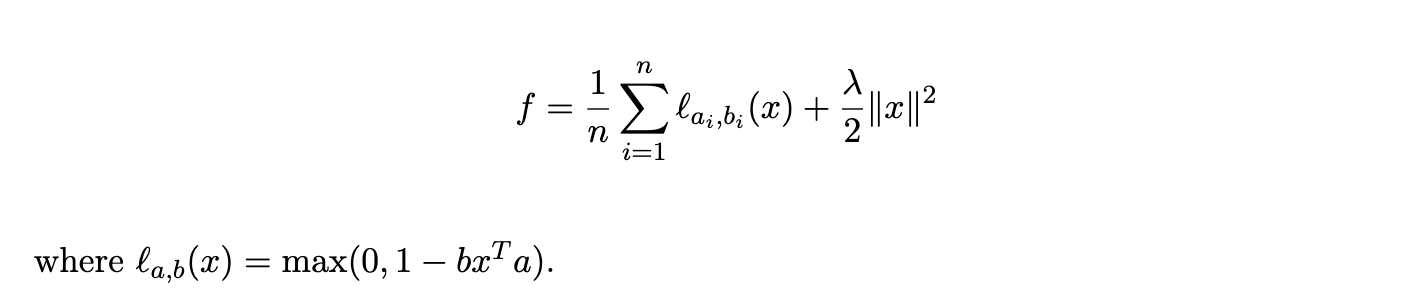

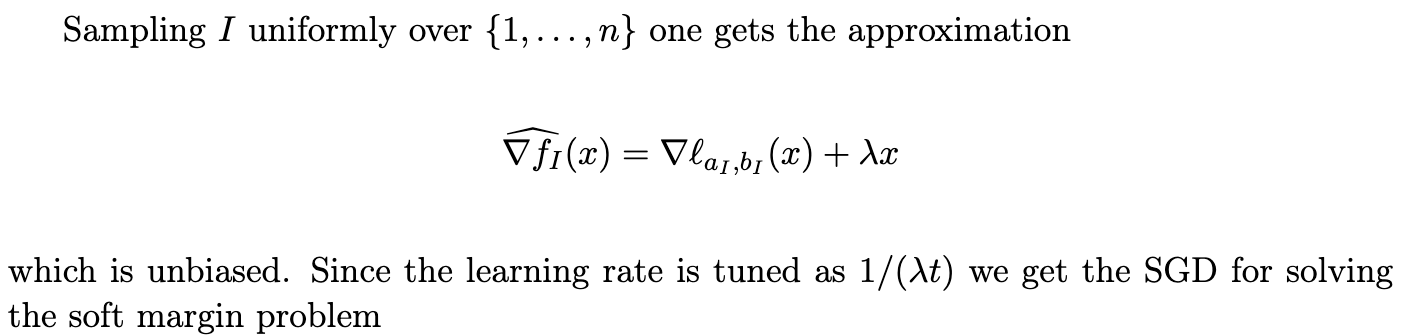

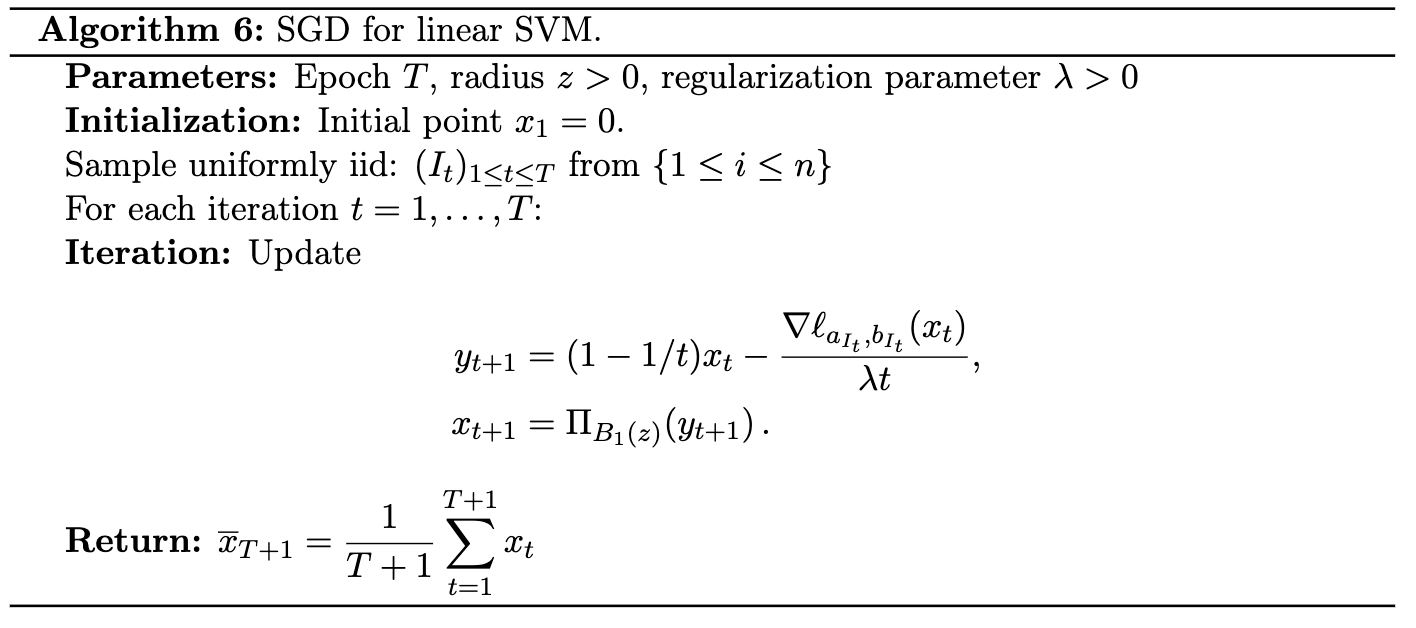

In [4]:
def sgd(model, X, y, epoch, l, verbose = 0, lr = 1):
    """
    Gradient descent algorithms applied with the CO pb il loss and uses tjhe gradloss function to update parameters
    :param model: the model
    :param X: (nxm) data
    :param y: (n)  labels
    :param lr: (float) learning rate
    :param epoch: (int) maximum number of iteration of the algorithm
    :param l:  (float) regularization parameter (lambda)
    :param verbose: (int) print epoch results every n epochs
    """
    losses = []
    wts = [model.w]

    n, _ = X.shape

    for i in range(epoch):

        idx = rd.randint(0, n-1)
        sample_x = X[idx, :].reshape(1, -1)
        sample_y = np.array(y[idx])

        t = i + 1
        dlr = lr/(l*t)
        new_wts = (1 - 1/t) * wts[-1] - dlr* model.gradLoss(sample_x, sample_y, l)

        wts.append(new_wts)
        model.w = new_wts
        current_loss = model.loss(X, y, l)
        losses += [current_loss]

        if verbose > 0 and i % verbose== 0:
            print(f"Epoch {i}, Loss {current_loss}")
    model.w = np.mean(wts, axis = 0)
    return losses, np.array(wts)

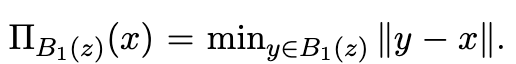

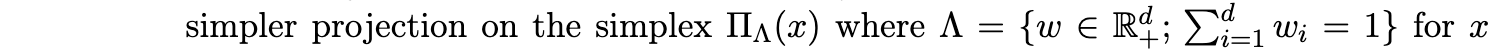

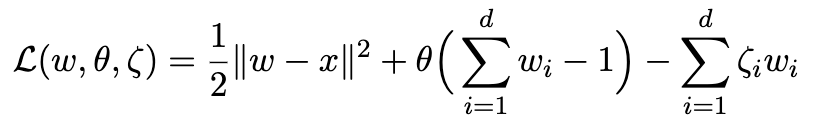

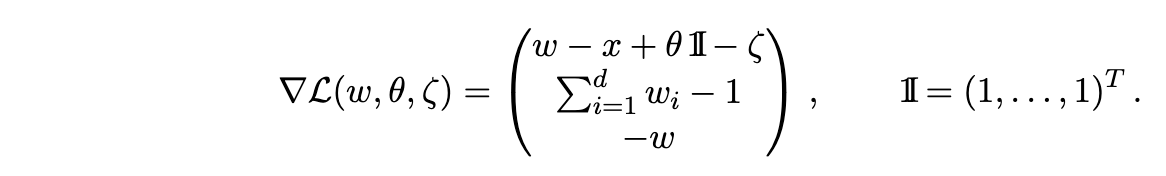

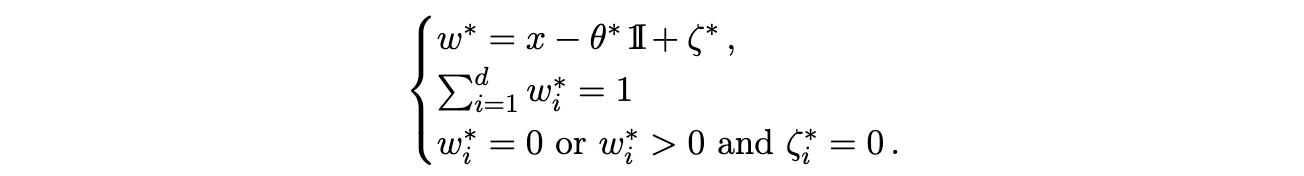

$w_i^* = SoftTreshold(x_i, \theta^*) = max(0, x_i-\theta^*)$

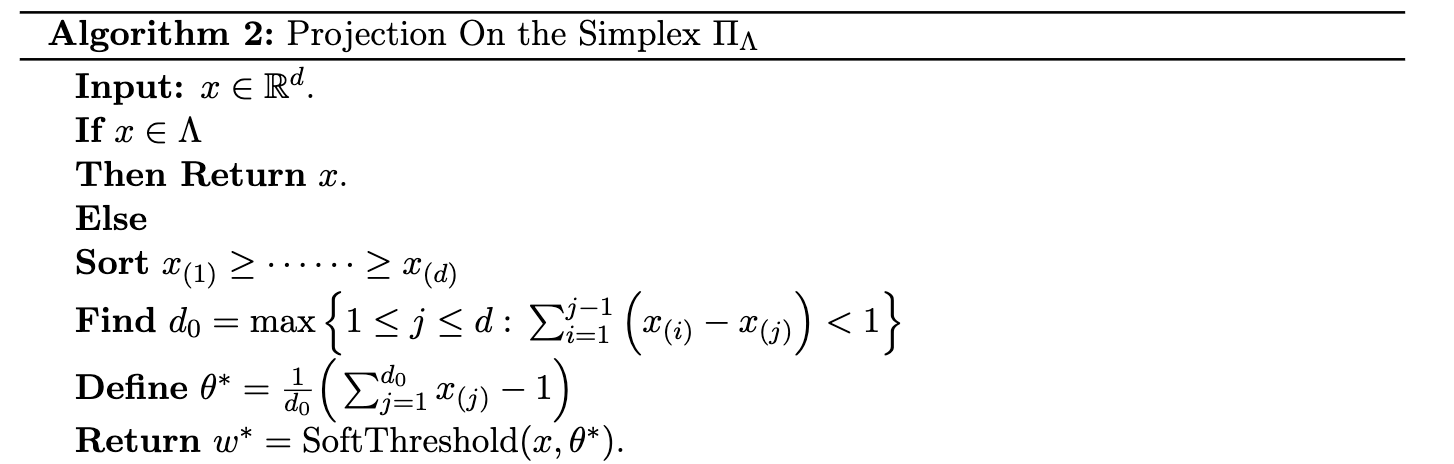

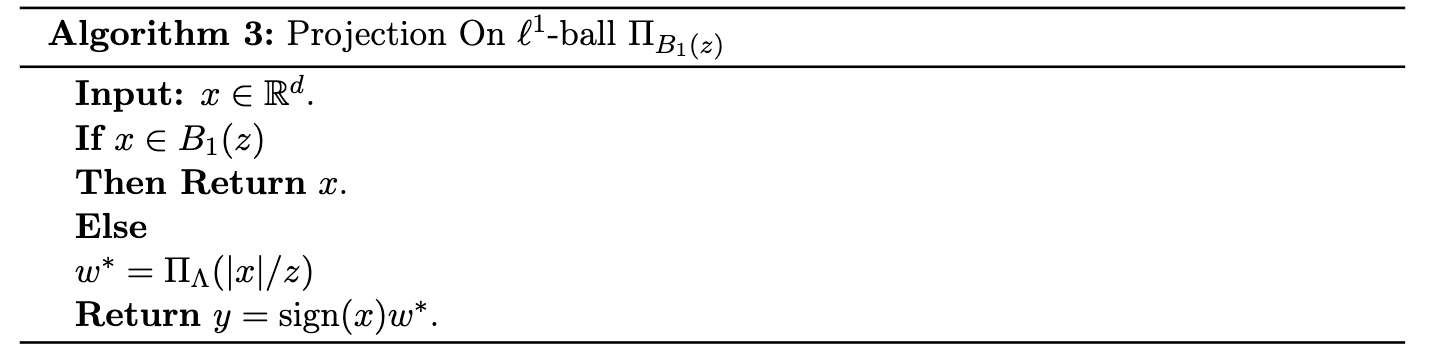

In [5]:
def proj_simplex(x):
    if np.sum(np.abs(x)) <= 1:
        return x

    x_s = np.sort(x, kind = 'quicksort')[::-1]
    cum_s = np.cumsum(x_s)
    res = x_s - (cum_s - 1)/ (np.arange(len(x))+1)
    d0 = np.max(np.where(res>0)) + 1
    theta = (cum_s[d0-1]-1)/d0
    return np.maximum(0, x - theta)


def proj_l1(x, z = 1):
    if np.sum(np.abs(x)) <= z:
        return x
    else:
        w = proj_simplex(abs(x)/z)
        return z * np.sign(x) * w


Stochastic Mirror Descent
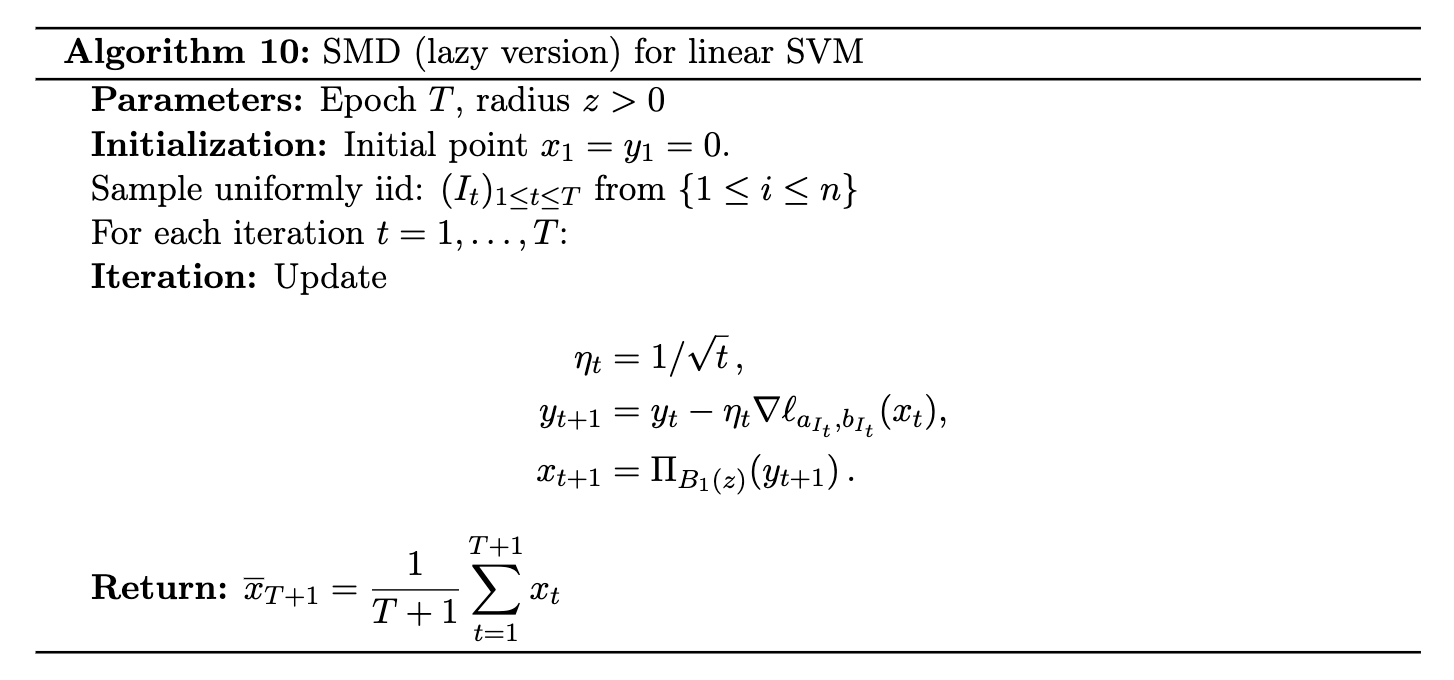

In [6]:
def smd(model, X, y, epoch, l, verbose = 0, lr = 1, z = 1):
    losses = []
    wts = [model.w]

    n, _ = X.shape

    for i in range(epoch):

        idx = rd.randint(0, n-1)
        sample_x = X[idx, :].reshape(1, -1)
        sample_y = np.array(y[idx])

        t = i + 1
        dlr = lr/(np.sqrt(t))
        new_wts = wts[-1] - dlr* model.gradLoss(sample_x, sample_y, l)


        new_wts = proj_l1(new_wts, z)
        wts.append(new_wts)
        model.w = new_wts
        current_loss = model.loss(X, y, l)
        losses += [current_loss]

        if verbose > 0 and i % verbose== 0:
            print(f"Epoch {i}, Loss {current_loss}")

    model.w = np.mean(wts, axis = 0)
    return losses, np.array(wts)



# Seminar 5: **Online Regularization**

# **FTL:**
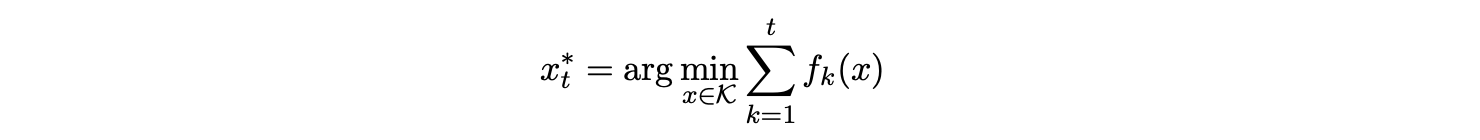

# **FTLL:**

 $$x_{t+1} = argmin_{x_t\in \Delta_n}\sum_{k=1}^{t}\nabla f_k(x_k)^T x$$

# FTRL:
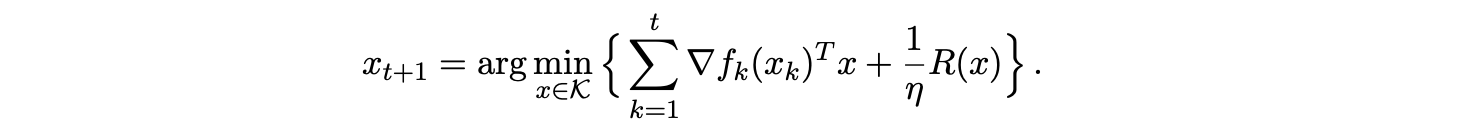

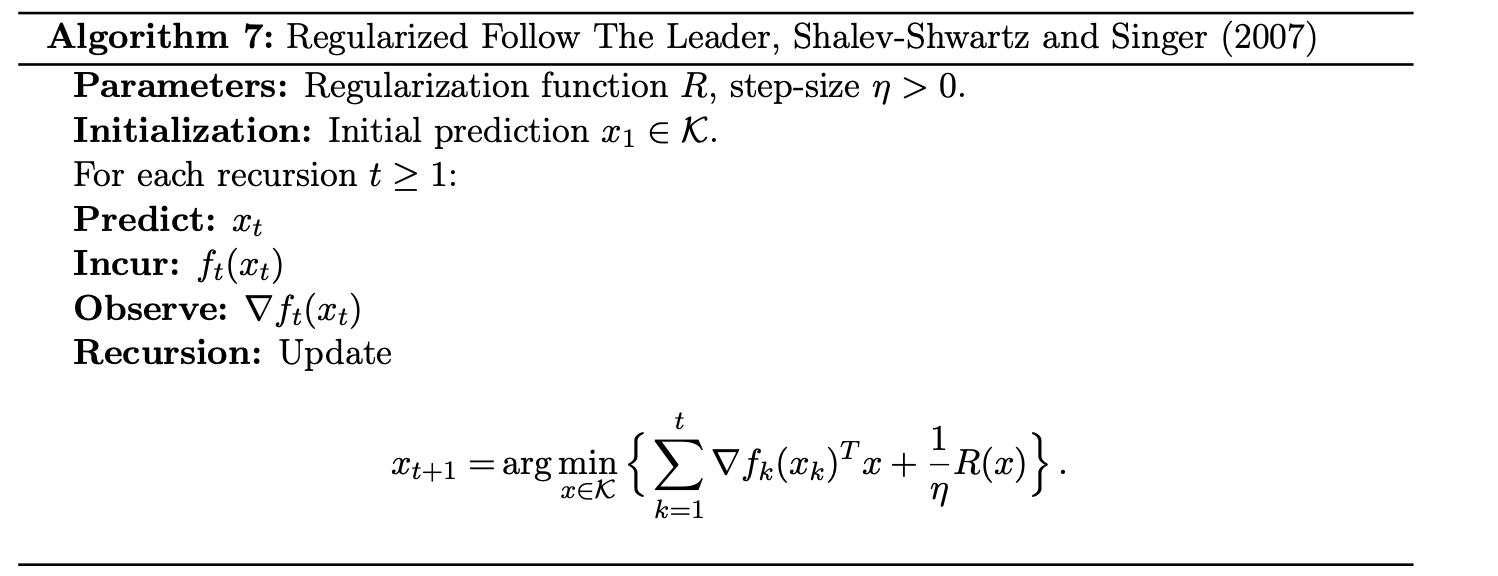

# **Online Mirror Descent** (lazy and agile)

## **Сопряженное пространство**

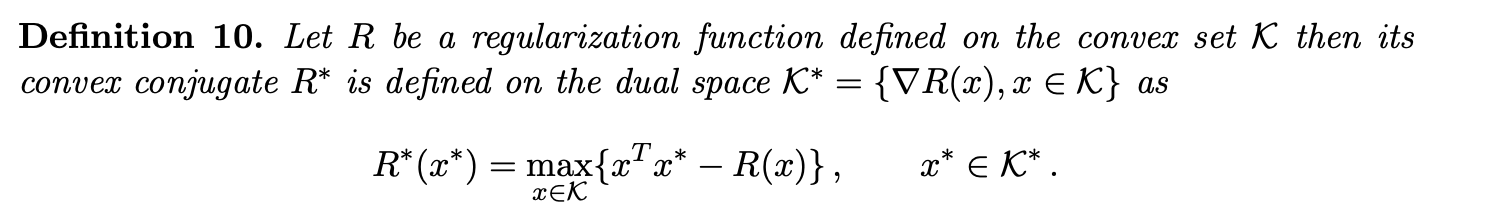

## **Неравенство Фенхеля-Янга**

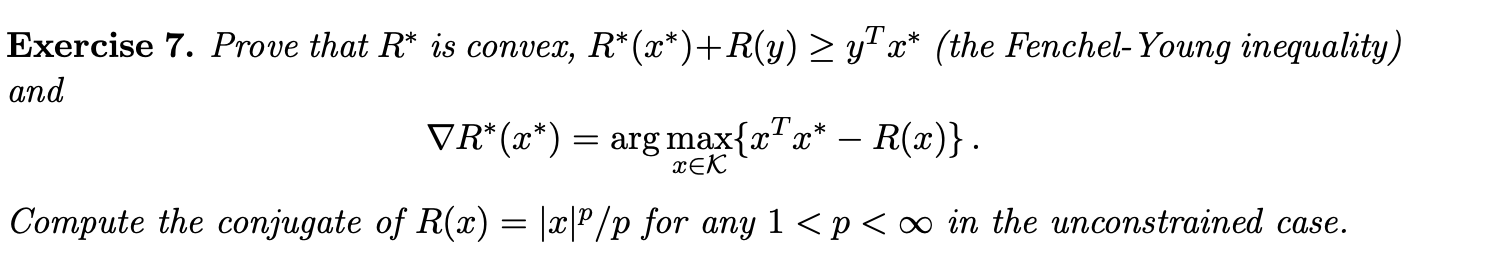

# **Для чего нужно?**

$y^Tx^* \leq R^*(x^*)+R(y)$

$x^* := \sum_{t=1}^T\nabla f_t(x_t)$

$y := x $

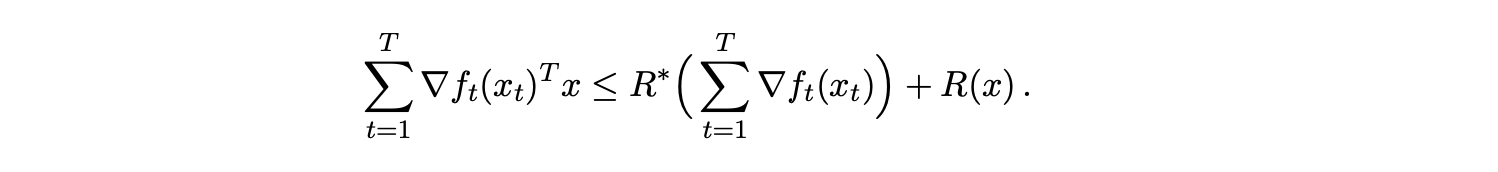

**OMD ~ GD в двойственном пространстве**

1) GD для $R^*$
2) Но $R^*$ работает с градиентами , а нам нужен сам $x$
3) Получить его позволяет дивергенция Брегмана

## **Дивергенция Брегмана**

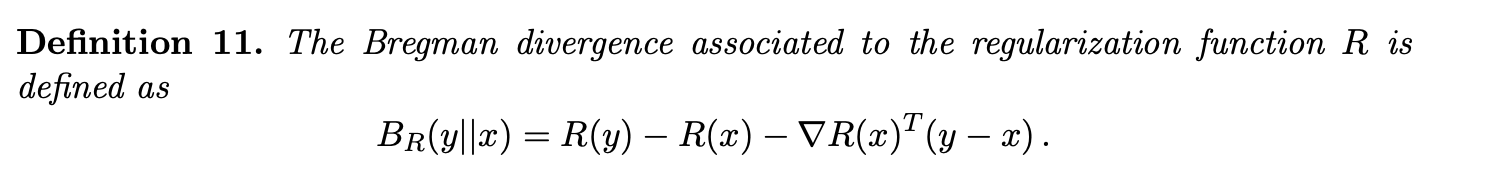

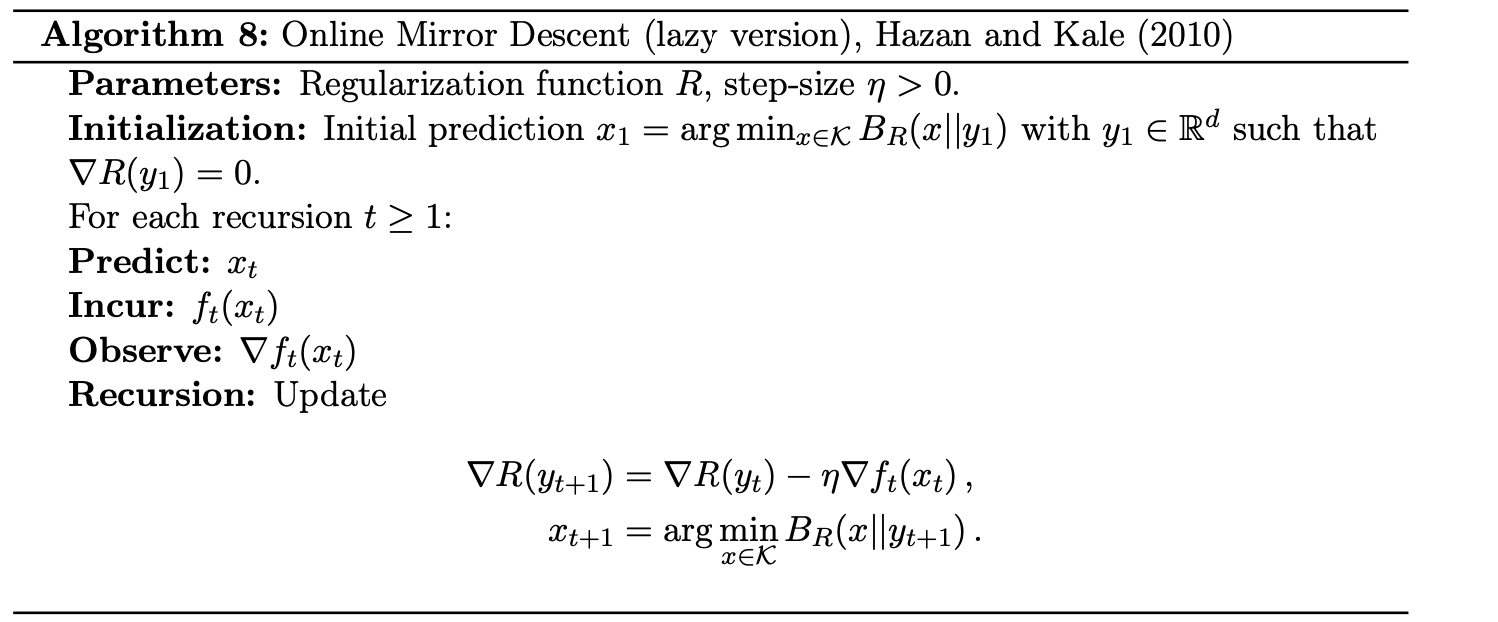

**Почему?** 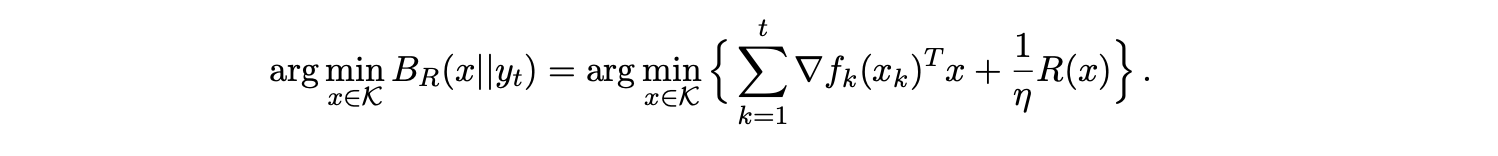

1) 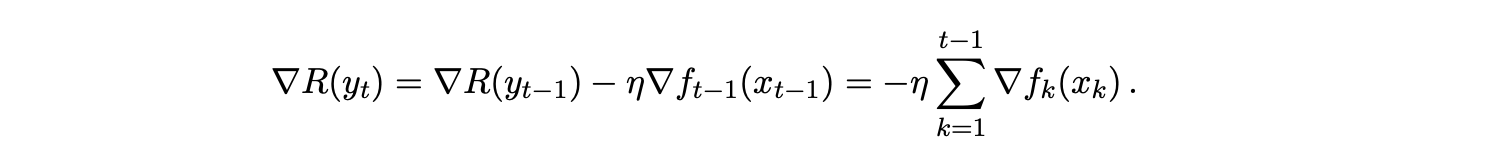

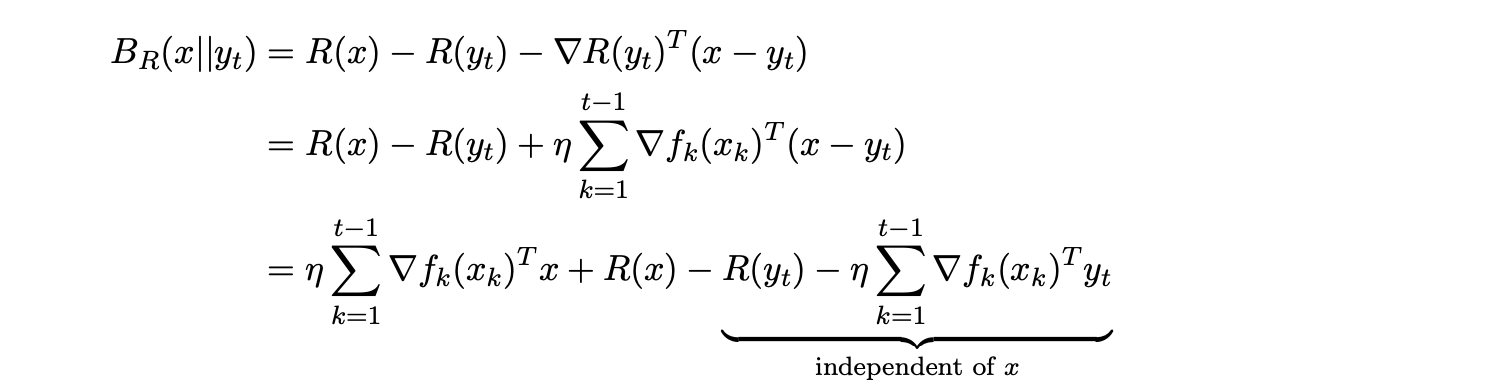

## **Пример**

$R(x) = \frac{1}{2}||x-x_1||^2$

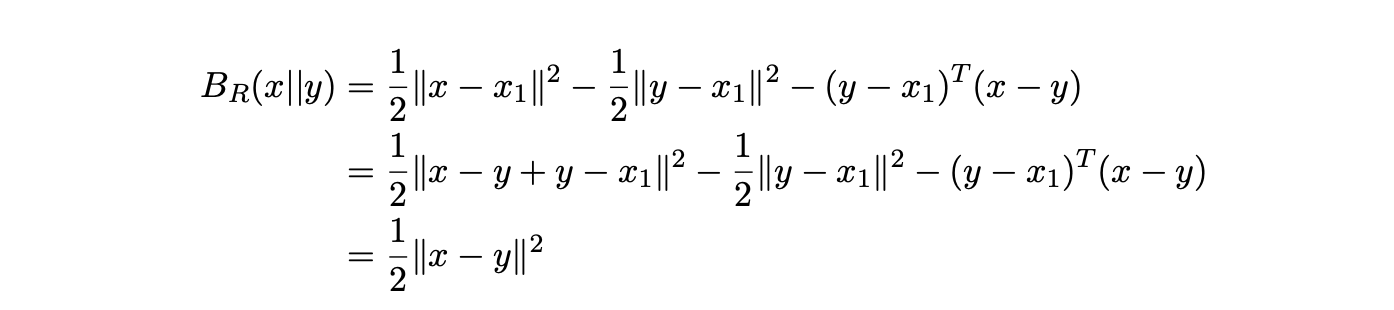

## **Получается**

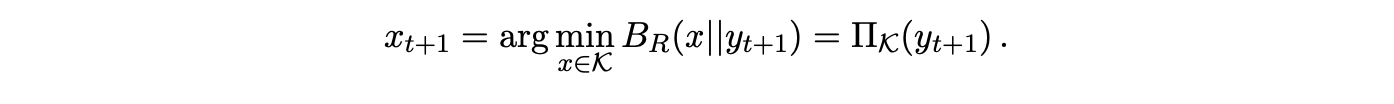

## **А еще**
$\nabla R(y_{t+1}) = (y_{t+1}-x_t) = -\eta \sum_{k=1}^t \nabla f_t(x_t)$

## **Итого:** Algorithm 8 -> Algorithm 9

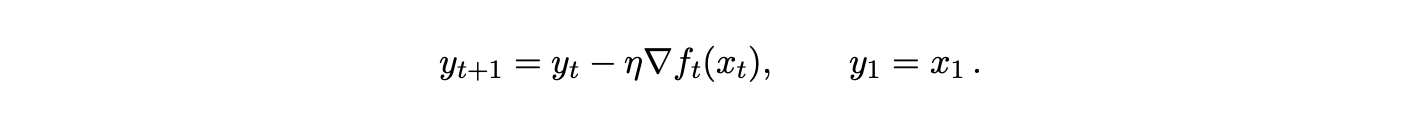

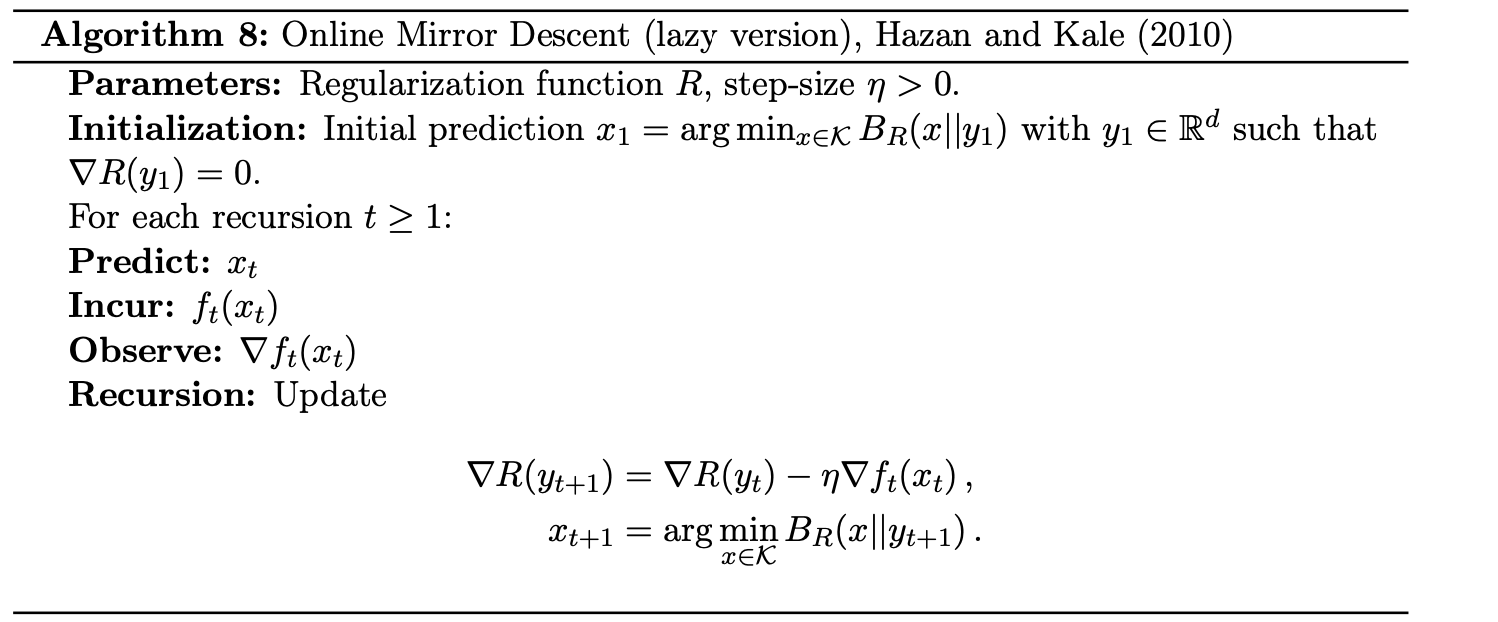

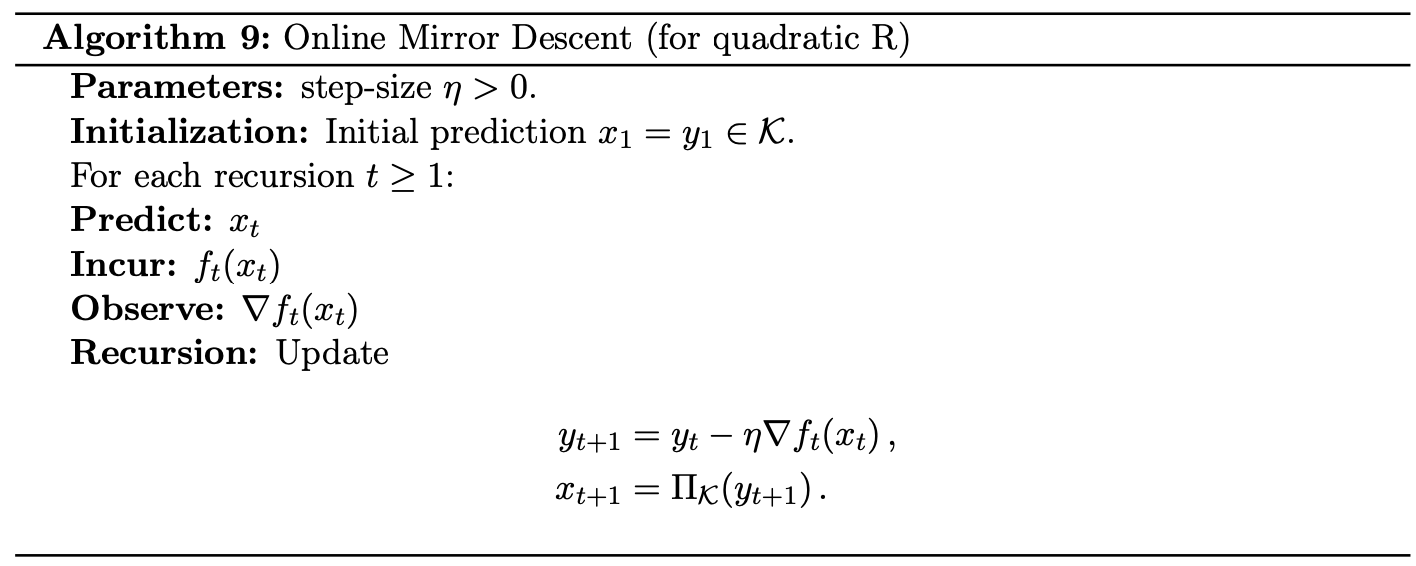

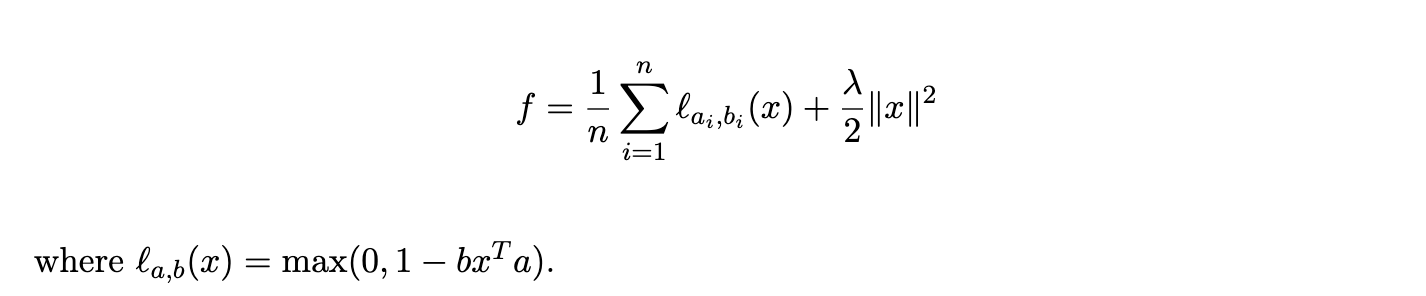

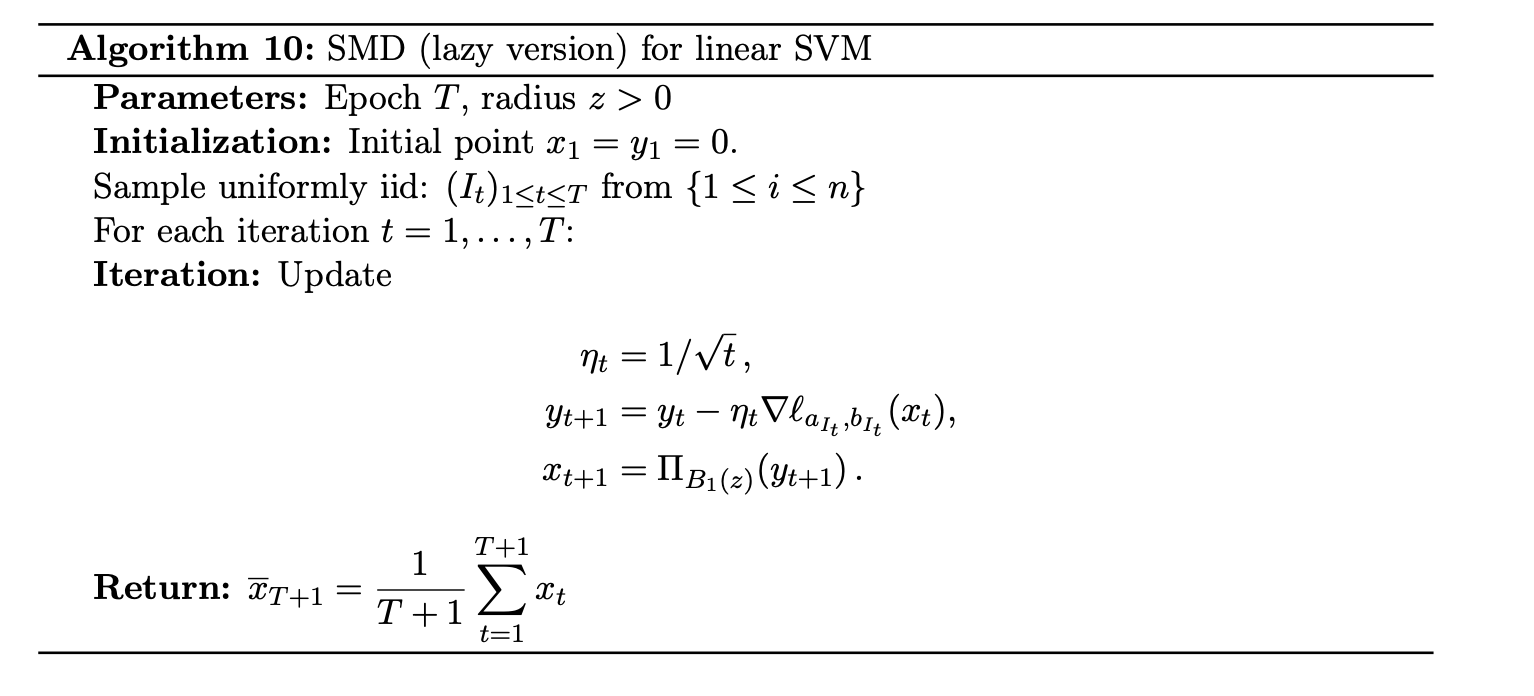

# **AdaGrad**

## **Оценка на регрет для OGD:** 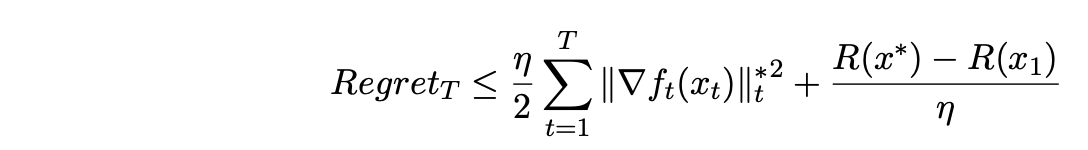

## **Если оптимизировать по параметру $\eta$:**

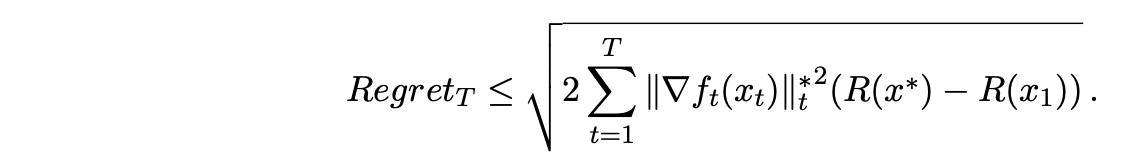


## **Сильно зависит от $R$!**

### А что если научится подбирать R?

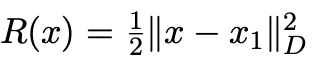

$\frac{1}{2}(x-x_1)^TD(x-x1)$

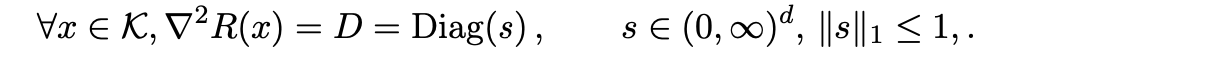

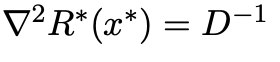

Например,
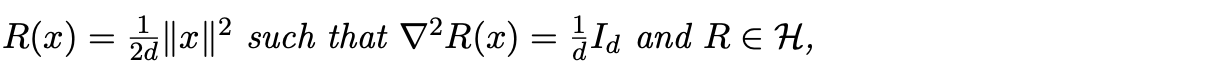

## **Как будем выбирать?**

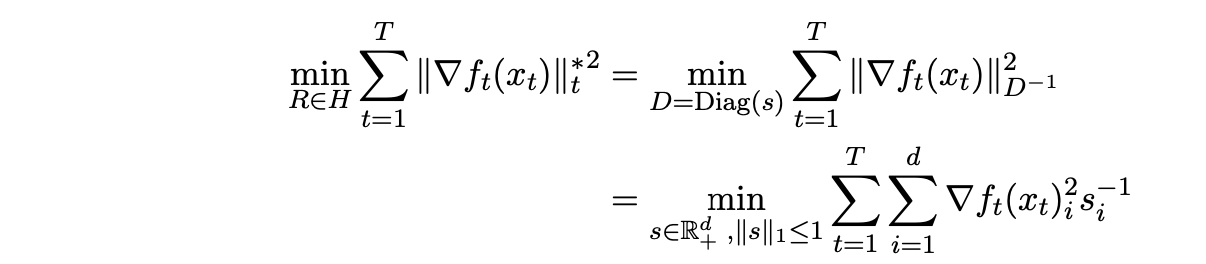

## **Неравенсвто Коши-Шварца:**
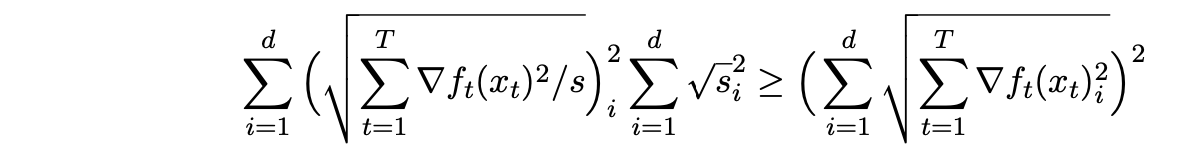

## Подставляем

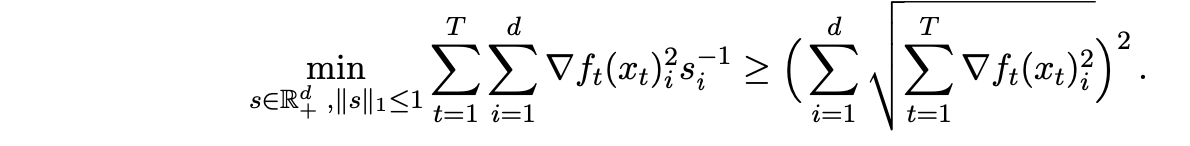

Но тогда

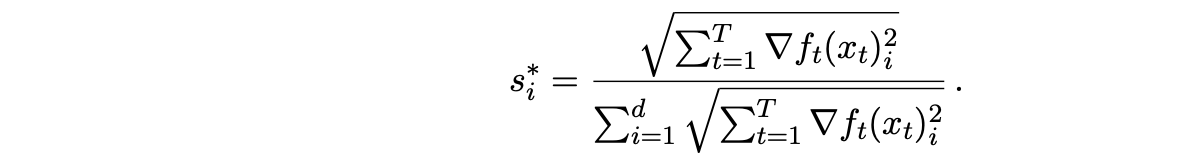

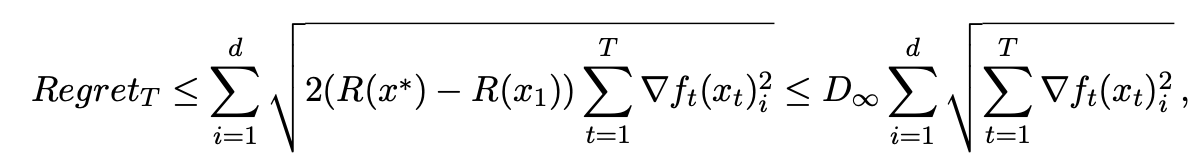

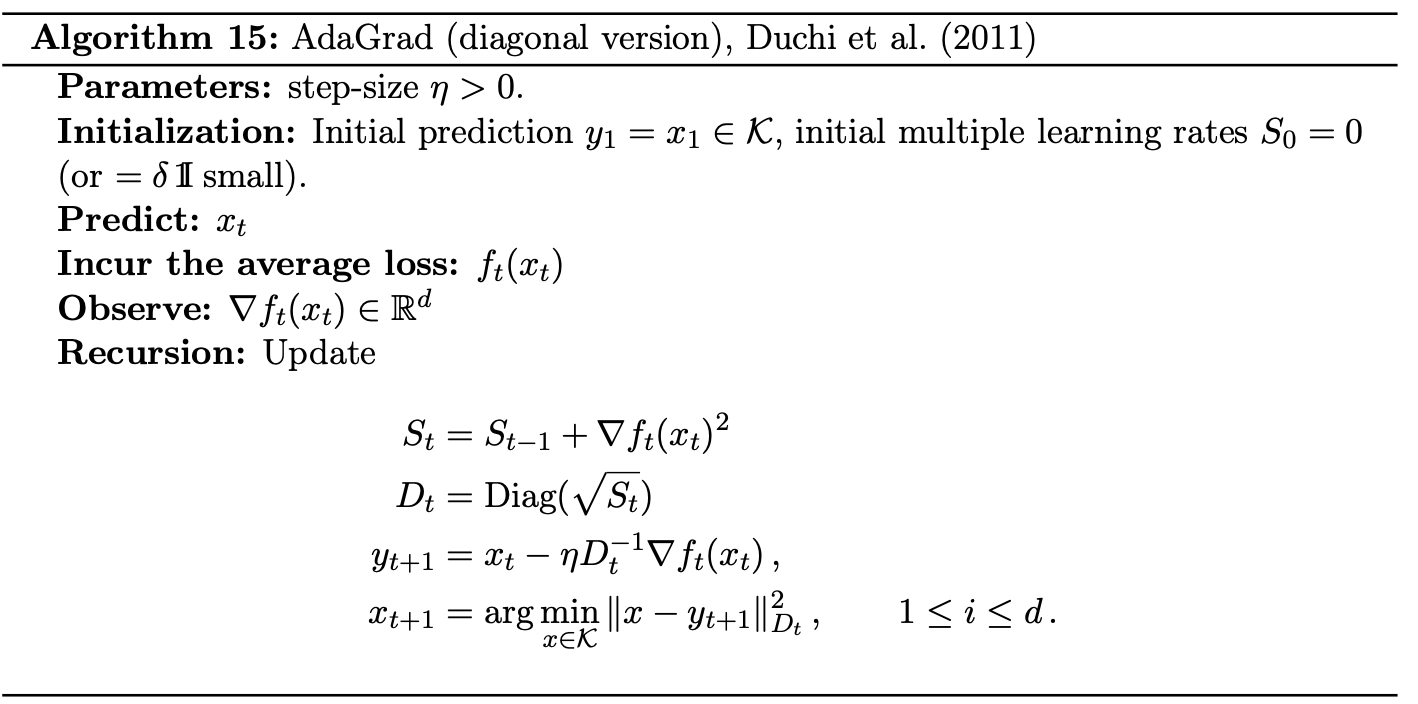

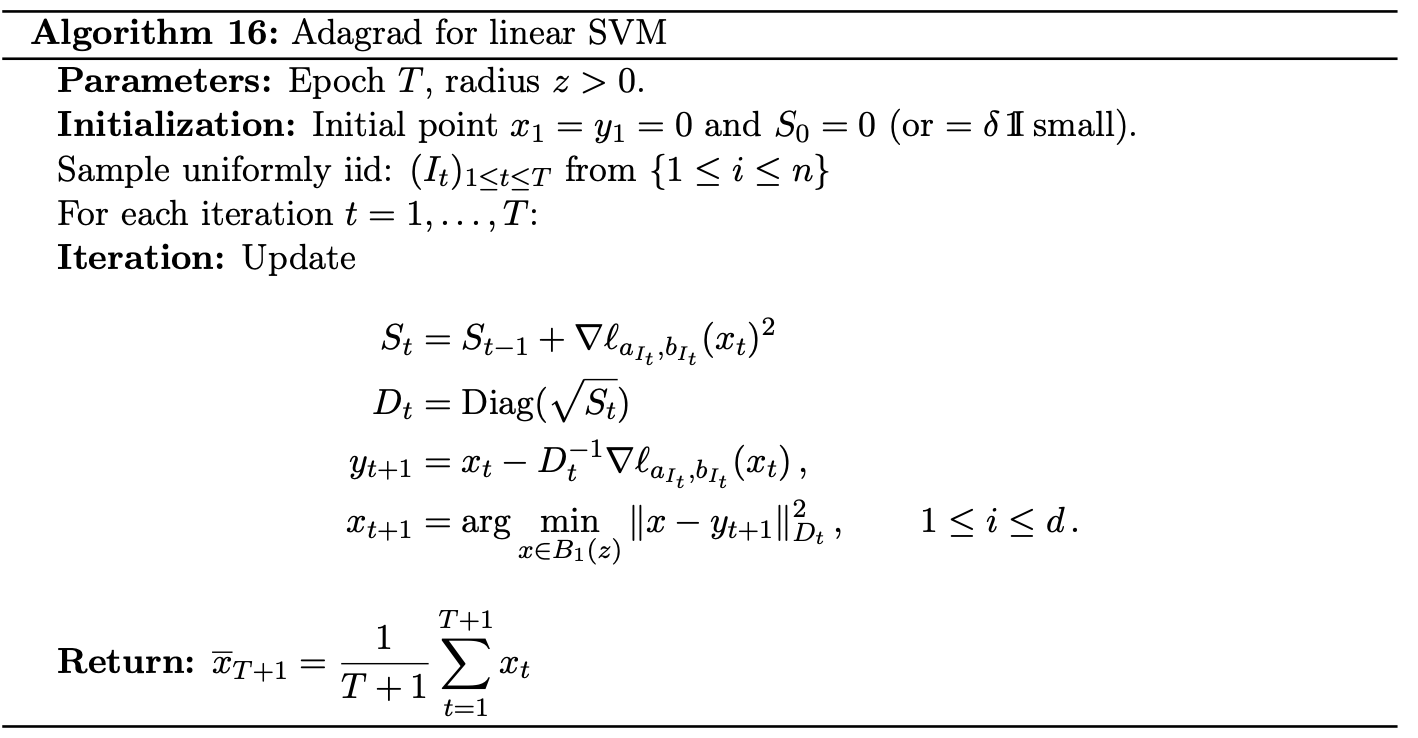

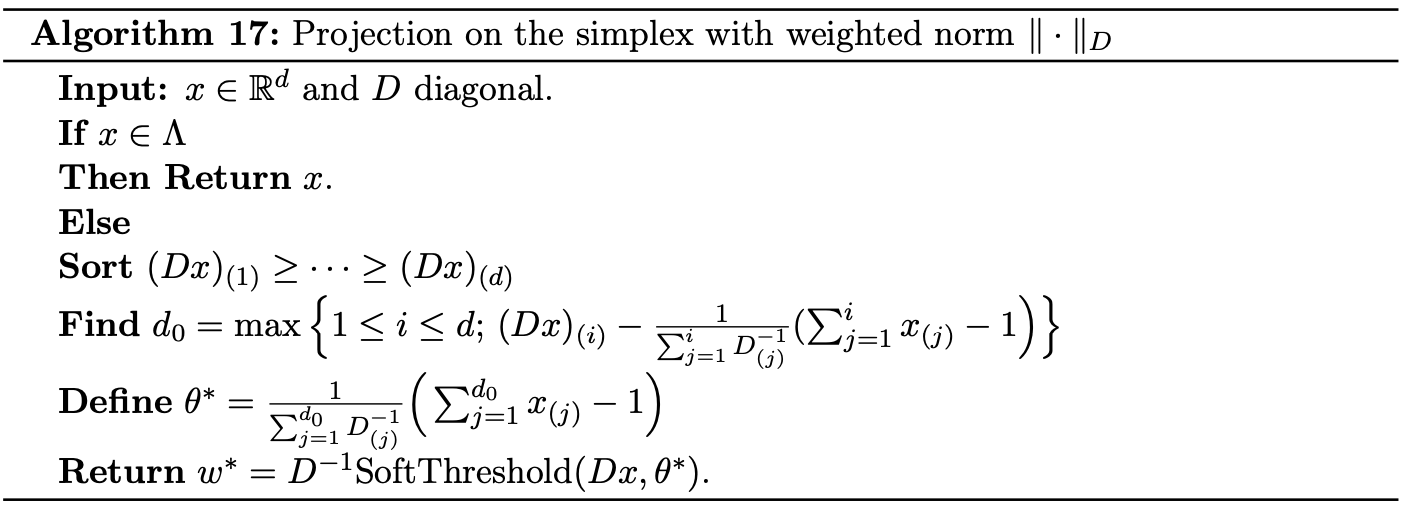

In [7]:
def weighted_proj_l1(x, d, z=1):
    """
    Weighted projection on the l1-ball of
    :param x: (size n) the input vector
    :param d: (size n) weights
    :param z: (int) radius of the L1 ball considered
    """
    if np.sum(np.abs(x)) <= z:
        return x
    else:
        proj = weighted_proj_simplex(abs(x) / z, np.diag(d))
    return z * np.sign(x) * proj


def weighted_proj_simplex(x, D):
    """
    :param x: a vector
    :param D: a matrix
    """

    dx = np.abs(np.dot(D, x))
    sorted_indices = np.argsort(-dx, kind='quicksort')
    sx = np.cumsum(x[sorted_indices])
    sd = np.cumsum(1 / np.diag(D)[sorted_indices])
    res = dx[sorted_indices] - (sx - 1) / sd
    d0 = np.max(np.where(res > 0)[0])
    theta = (sx[d0] - 1) / sd[d0]

    return np.dot(np.linalg.inv(D), np.maximum(0, dx - theta))

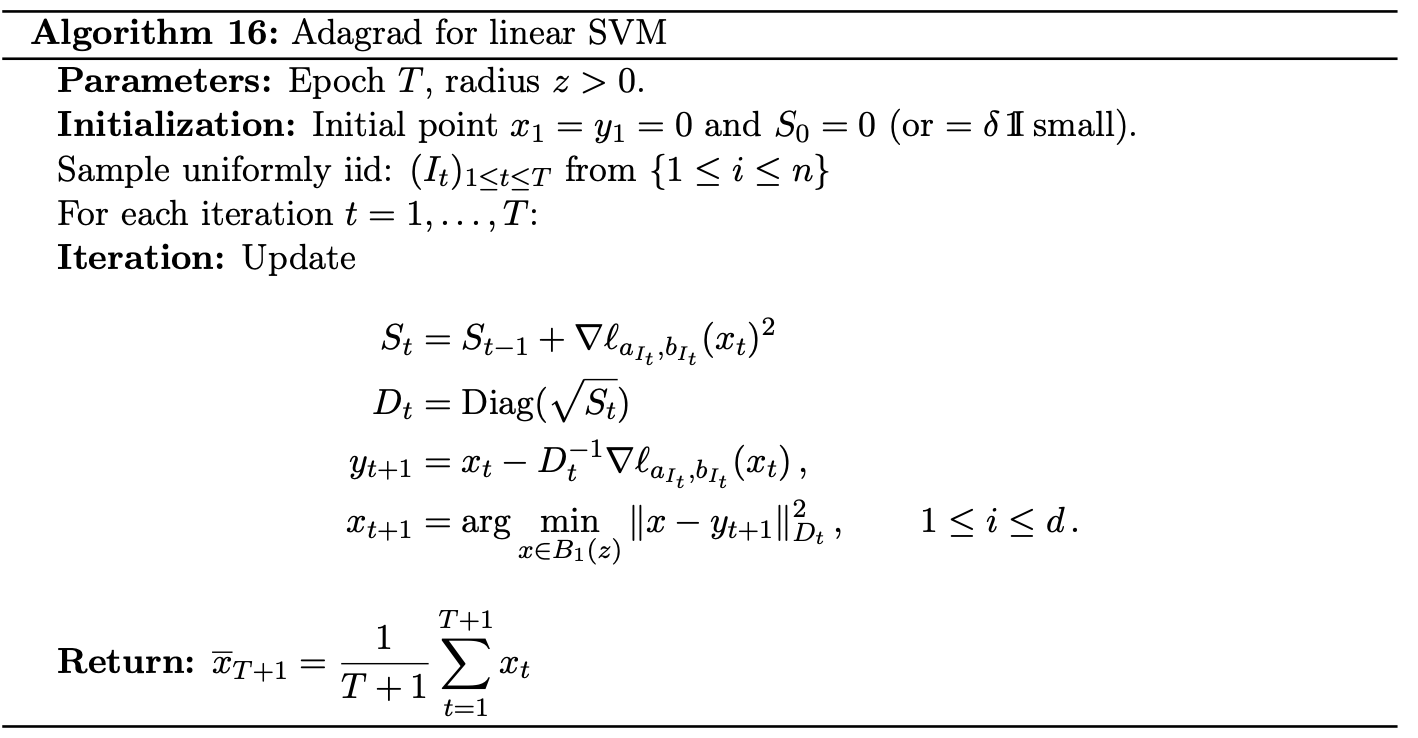

In [8]:
def adagrad(model, X, y, epoch, l, z=1, lr=1, verbose=0):
    """
    Gradient descent algorithms applied with the CO pb il loss and uses tjhe gradloss function to update parameters
    :param model: the model
    :param X: (nxm) data
    :param y: (n)  labels
    :param lr: (float) learning rate
    :param epoch: (int) maximum number of iteration of the algorithm
    :param l:  (float) regularization parameter (lambda)
    :param z: (float) radius of the l1-ball
    :param verbose: (int) print epoch results every n epochs
    """

    losses = []
    n, d = X.shape
    wts = [np.zeros(d)]
    Sts = np.zeros(d)

    for i in range(epoch):

        idx = rd.randint(0, n-1)
        sample_x = X[idx, :].reshape(1, -1)
        sample_y = np.array(y[idx])

        Sts += model.gradLoss(sample_x, sample_y, l)**2
        Dt = np.diag(np.sqrt(Sts))
        yts = wts[-1]-lr*np.linalg.inv(Dt).dot(model.gradLoss(sample_x, sample_y, l))

        new_wts = weighted_proj_l1(yts, np.diag(Dt), z)
        wts.append(new_wts)

        model.w = new_wts

        current_loss = model.loss(X, y, l)
        losses += [current_loss]

        if verbose > 0 and i % verbose== 0:
            print(f"Epoch {i}, Loss {current_loss}")

    model.w = np.mean(wts, axis = 0)
    return losses, np.array(wts)

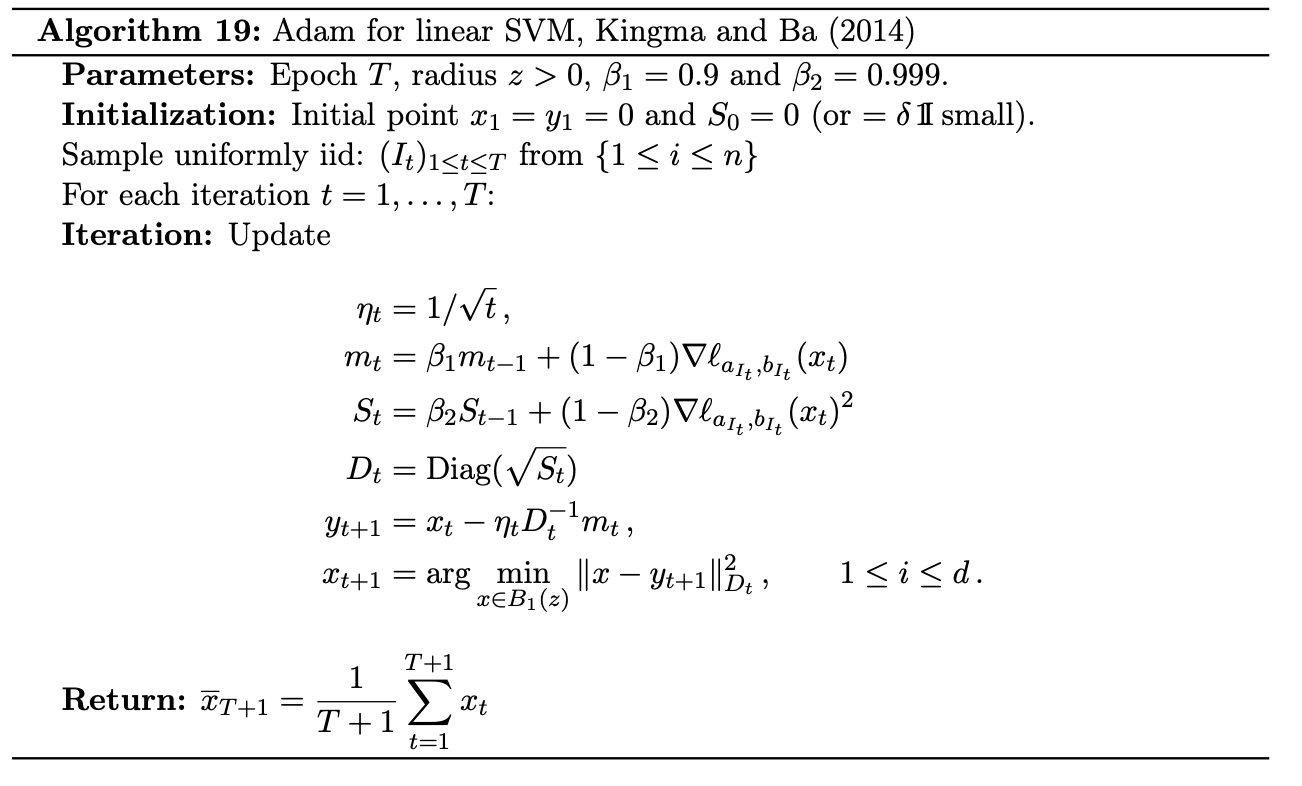

# **Ниже реализуй Adam**

In [9]:
#def adam(model, X, y, params):
#  pass

### **Ниже добавь необходимые параметры. Добавь для Adam, что нужно**

In [10]:
np.random.seed(123)
nepoch = 100

lr = 0.1
lbd = 1/3
z = 100
gamma = 1/8
verbose = 500

#Adam


# Подготовим датасет

**в подготовке датасета ничего менять не нужно**

In [13]:
mnist_train = pd.read_csv('mnist_train.csv', sep=',', header=None)   # Reading
# Extract data
train_data = mnist_train.values[:, 1:]
# Normalize data
train_data = train_data / np.max(train_data)
train_data

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [14]:
train_data.shape

(60000, 784)

In [15]:
train_data = np.c_[train_data, np.ones(train_data.shape[0])]
train_data

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [16]:
# Keep only digits 1 and 2
train_mask = np.isin(mnist_train.values[:, 0], [1, 2])
train_data = mnist_train.values[train_mask, 1:]
train_data = train_data / np.max(train_data)
train_data = np.c_[train_data, np.ones(train_data.shape[0])]
train_labels = mnist_train.values[train_mask, 0]
train_labels = np.where(train_labels == 1, 1, -1)

mnist_test = pd.read_csv('mnist_test.csv', sep=',', header=None)
test_mask = np.isin(mnist_test.values[:, 0], [1, 2])
test_data = mnist_test.values[test_mask, 1:]
test_data = test_data / np.max(test_data)
test_data = np.c_[test_data, np.ones(test_data.shape[0])]
test_labels = mnist_test.values[test_mask, 0]
test_labels = np.where(test_labels == 1, 1, -1)

time_dict = {}

n, m = train_data.shape
print('Ready!')

Ready!


ниже заготовка под граффики Loss, Accuracy, Time

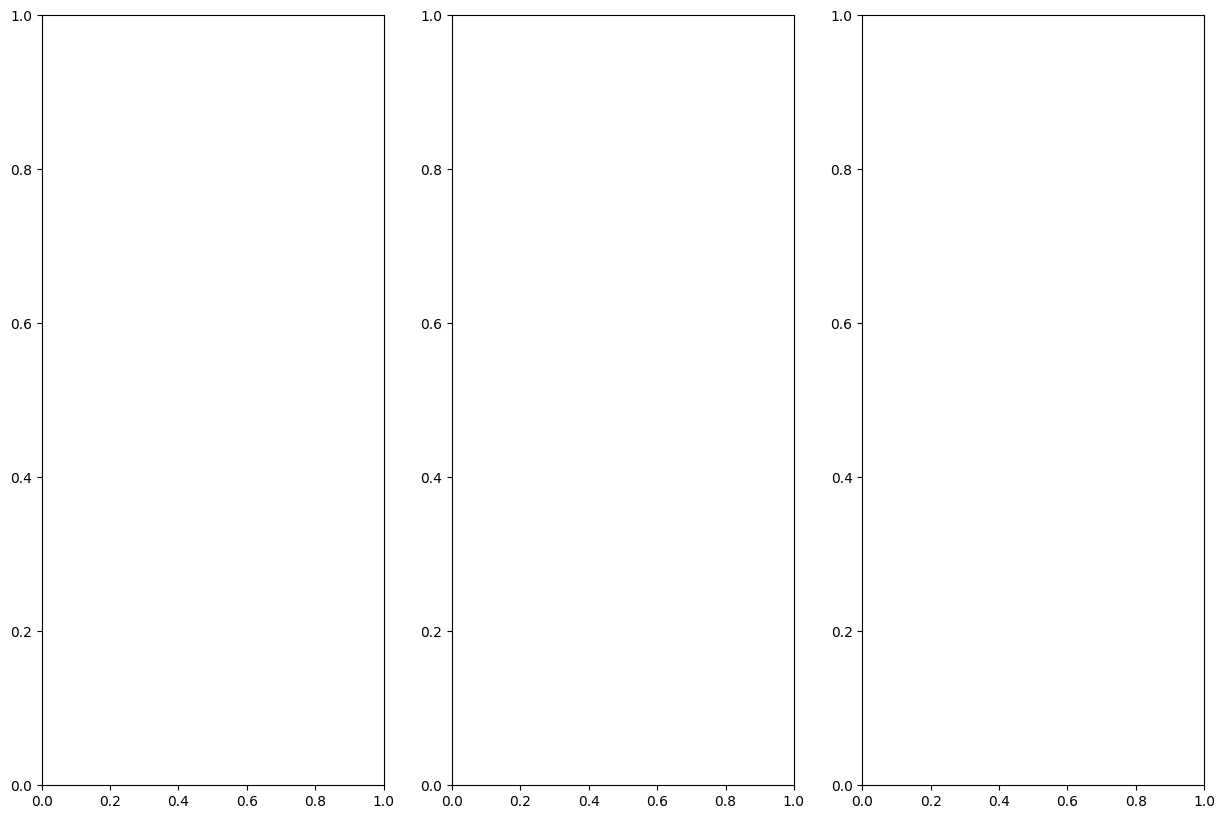

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 10))

In [18]:
import time

In [19]:
from utils import *

### **Gradient Descent (GD)**

In [20]:
print("-----------GD----------- \n")
model = LinearSVM(m)
tic = time.time()

GDloss, wts = gd(model, train_data, train_labels, nepoch, lbd, verbose, lr)

time_dict['gd'] = (time.time() - tic)

pred_test_labels = model.predict(test_data)

GDacc = accuracy(test_labels, pred_test_labels)

print('After {:3d} epoch, Unconstrained GD algorithm has a loss of {:1.6f} and accuracy {:1.6f}'.format(nepoch, GDloss[-1], GDacc))

ax[0].plot(np.arange(nepoch), GDloss, label = 'gd')
GDaccuracies = compute_accuracies(wts, test_data, test_labels)
ax[1].plot(GDaccuracies, label = 'gd')

###GDtime = compute_time()
### ax[2].plot(SGDtime, label = 'sgd')

-----------GD----------- 

Epoch 0, Loss 111.96654038460005
After 100 epoch, Unconstrained GD algorithm has a loss of 49.144442 and accuracy 0.401938


### **Stochastic Gradient Descenty (SGD)**

In [21]:
print("-----------SGD----------- \n")
model = LinearSVM(m)
tic = time.time()

SGDloss, wts = sgd(model, train_data, train_labels, nepoch, lbd, verbose, 1)
time_dict['sgd'] = (time.time() - tic)
pred_test_labels = model.predict(test_data)
acc = accuracy(test_labels, pred_test_labels)
print('After {:3d} epoch, Unconstrained SGD algorithm has a loss of {:1.6f} and accuracy {:1.6f}'.format(nepoch, SGDloss[-1], acc))

ax[0].plot(np.arange(nepoch), SGDloss, label = 'sgd')
SGDaccuracies = compute_accuracies(wts, test_data, test_labels)
ax[1].plot(SGDaccuracies, label = 'sgd')


###SGDtime = compute_time()
### ax[2].plot(SGDtime, label = 'sgd')

-----------SGD----------- 

Epoch 0, Loss 119.59461359434148
After 100 epoch, Unconstrained SGD algorithm has a loss of 0.889102 and accuracy 0.476234


### **Stochastic Miror Descent (SMD)**

In [22]:
print("-----------SMD----------- \n")
model = LinearSVM(m)
tic = time.time()

SMDprojloss, wts = smd(model, train_data, train_labels, nepoch, lbd, z, lr, verbose)
time_dict['smd'] = (time.time() - tic)
pred_test_labels = model.predict(test_data)
acc = accuracy(test_labels, pred_test_labels)
print('After {:3d} epoch, constrained SMD algorithm has a loss of {:1.6f} and accuracy {:1.6f}'.format(nepoch, SMDprojloss[-1], acc))

ax[0].plot(np.arange(nepoch), SMDprojloss, label = 'smd')
SMDprojaccuracies = compute_accuracies(wts, test_data, test_labels)
ax[1].plot(SMDprojaccuracies, label = 'smd')


###SMDtime = compute_time()
### ax[2].plot(SMDtime, label = 'smd')

-----------SMD----------- 

Epoch 0, Loss 98.76625463571112
After 100 epoch, constrained SMD algorithm has a loss of 30.969478 and accuracy 0.590678


### **Adaptative Gradient (Adagrad)**

In [24]:
print("-----------Adagrad - z=" + str(z)+"----------- \n")
model = LinearSVM(m)
tic = time.time()

ADAloss, wts = adagrad(model, train_data, train_labels, nepoch, lbd, z, 1, verbose)
time_dict['adagrad'] = (time.time() - tic)
pred_test_labels = model.predict(test_data)
print('After {:3d} epoch, constrained Adagrad (radius {:3d}) algorithm has a loss of {:1.6f} and accuracy {:1.6f}'.format(nepoch, z, ADAloss[-1], acc))


ax[0].plot(np.arange(nepoch), ADAloss, label = 'adagrad')

ADAaccuracies = compute_accuracies(wts, test_data, test_labels)
ax[1].plot(ADAaccuracies, label = 'adagrad')


###Adagradtime = compute_time()
### ax[2].plot(Adagradtime, label = 'smd')


-----------Adagrad - z=100----------- 

Epoch 0, Loss 10.965660212160405
After 100 epoch, constrained Adagrad (radius 100) algorithm has a loss of 1.429579 and accuracy 0.590678


### **Adam**

**Ниже протестируй Adam**

In [25]:
print("-----------Adam----------- \n")

-----------Adam----------- 



### Curves

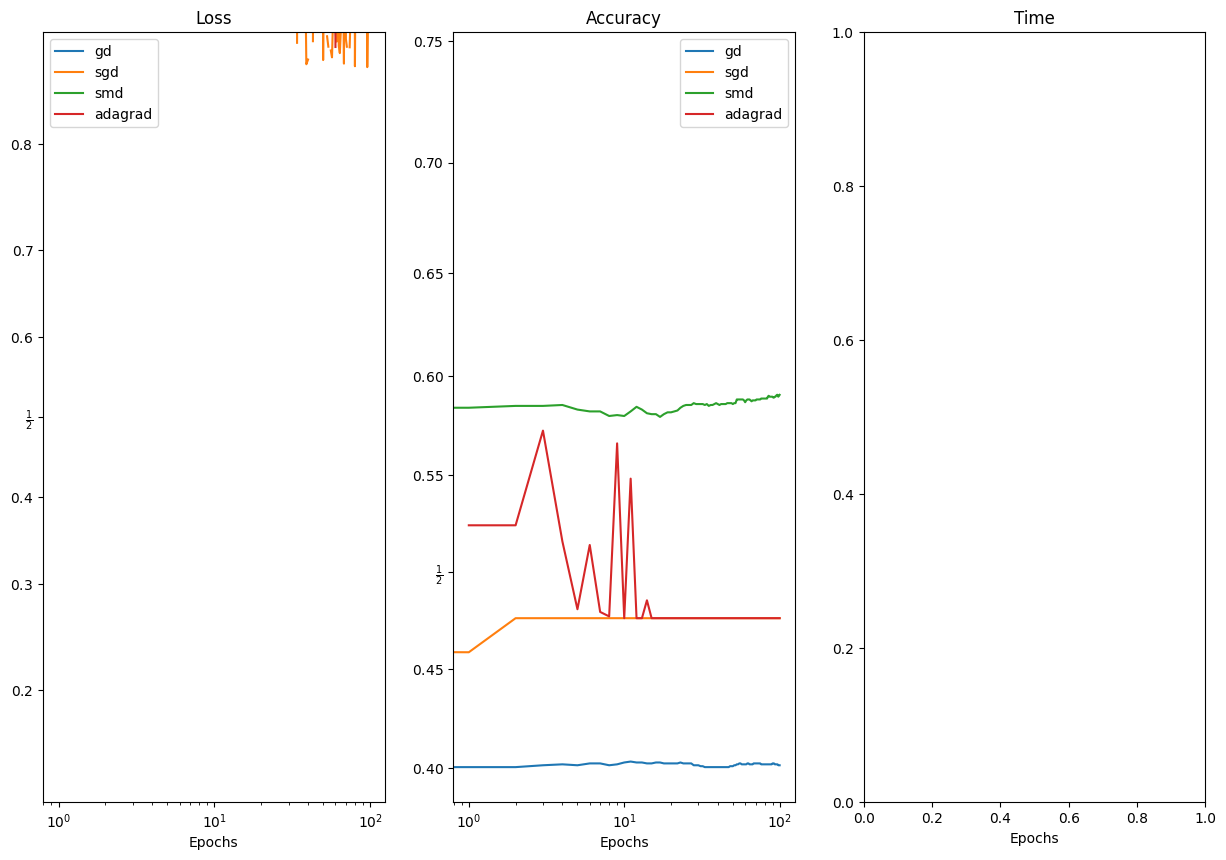

In [27]:
# Log scale
ax[0].set_xscale('log')
ax[0].set_yscale('logit')
ax[1].set_xscale('log')
ax[1].set_yscale('logit')
#ax[2].set_xscale('log')
#ax[2].set_yscale('logit')

# legend
ax[0].legend()
ax[1].legend()
#ax[2].legend()
ax[0].set_title('Loss')
ax[1].set_title('Accuracy')
ax[2].set_title('Time')
ax[0].set_xlabel('Epochs')
ax[1].set_xlabel('Epochs')
ax[2].set_xlabel('Epochs')


fig

**У тебя все работает? Появились результаты Adam? Отлично, если алгоритм реализован верно 5 баллов!**

**Добавь время выполнения по эпохам и получи + 2 балла!**

**Не забудь изменить протокол тестирования, чтобы получить + 3 балла!**



# **Ниже тестирование алгоритмов для измененного протокола тестирования!**

Если на семинаре мы рассматривали стандартный подход, тренировали на трейновом датасете, а потом смотрели, что получалось на тесте.

То сейчас мы и тренируем модель на трейне и сразу тестируемся. Т.е в на первом шаге мы делаем какое-то предсказние -> затем у нас появляется первый семпл с датасета -> мы сравниваем наше предсказание и залогированный лейбл, теперь у нас появляется целый один семпл в тренировочном датасете. Далее, мы тренируемся на этом одном семпле, делаем предсказание на второй лейбл, сравниваем... у нас теперь целых два семпла в тренировочном датасете И.Т.Д Для такого протокола тестирования достаточно использовать mnist_train.csv